# **Load Data**

> EDA

In [33]:
import pandas as pd
df = pd.read_csv('../data/raw/Musical_instruments_reviews.csv')#/content/drive/MyDrive/NLP-1208408/Musical_instruments_reviews.csv
print ("The shape of the  data is :"+ str(df.shape))
print (df.info())


The shape of the  data is :(10261, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10261 entries, 0 to 10260
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reviewerID      10261 non-null  object 
 1   asin            10261 non-null  object 
 2   reviewerName    10234 non-null  object 
 3   helpful         10261 non-null  object 
 4   reviewText      10254 non-null  object 
 5   overall         10261 non-null  float64
 6   summary         10261 non-null  object 
 7   unixReviewTime  10261 non-null  int64  
 8   reviewTime      10261 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 721.6+ KB
None


### **Dataset Details**
**Description of columns in the file:**
* reviewerID - ID of the reviewer, e.g. A2SUAM1J3GNN3B
* asin - ID of the product, e.g. 1384719342
* reviewerName - name of the reviewer
* helpful - helpfulness rating of the review, e.g. 2/3
* reviewText - text of the review
* overall - rating of the product
* summary - summary of the review
* unixReviewTime - time of the review (unix time)
* reviewTime - time of the review (raw)

> **Sentiment Analysis** can automatically identify the emotion or attitude expressed in text as positive, negative, or neutral. It helps businesses understand customer feelings by analyzing feedback data collected from various platforms.


In [34]:
df

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...","[0, 0]","Not much to write about here, but it does exac...",5.0,good,1393545600,"02 28, 2014"
1,A14VAT5EAX3D9S,1384719342,Jake,"[13, 14]",The product does exactly as it should and is q...,5.0,Jake,1363392000,"03 16, 2013"
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""","[1, 1]",The primary job of this device is to block the...,5.0,It Does The Job Well,1377648000,"08 28, 2013"
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""","[0, 0]",Nice windscreen protects my MXL mic and preven...,5.0,GOOD WINDSCREEN FOR THE MONEY,1392336000,"02 14, 2014"
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,"[0, 0]",This pop filter is great. It looks and perform...,5.0,No more pops when I record my vocals.,1392940800,"02 21, 2014"
...,...,...,...,...,...,...,...,...,...
10256,A14B2YH83ZXMPP,B00JBIVXGC,Lonnie M. Adams,"[0, 0]","Great, just as expected. Thank to all.",5.0,Five Stars,1405814400,"07 20, 2014"
10257,A1RPTVW5VEOSI,B00JBIVXGC,Michael J. Edelman,"[0, 0]",I've been thinking about trying the Nanoweb st...,5.0,"Long life, and for some players, a good econom...",1404259200,"07 2, 2014"
10258,AWCJ12KBO5VII,B00JBIVXGC,Michael L. Knapp,"[0, 0]",I have tried coated strings in the past ( incl...,4.0,Good for coated.,1405987200,"07 22, 2014"
10259,A2Z7S8B5U4PAKJ,B00JBIVXGC,"Rick Langdon ""Scriptor""","[0, 0]","Well, MADE by Elixir and DEVELOPED with Taylor...",4.0,Taylor Made,1404172800,"07 1, 2014"


# **Cleaning and Preparing Data**

 > Combine the `reviewText` and `summary` columns into a single column, and remove irrelevant information.


In [35]:
df['reviews']=df['reviewText']+df['summary']
df.head(5)

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,reviews
0,A2IBPI20UZIR0U,1384719342,"cassandra tu ""Yeah, well, that's just like, u...","[0, 0]","Not much to write about here, but it does exac...",5.0,good,1393545600,"02 28, 2014","Not much to write about here, but it does exac..."
1,A14VAT5EAX3D9S,1384719342,Jake,"[13, 14]",The product does exactly as it should and is q...,5.0,Jake,1363392000,"03 16, 2013",The product does exactly as it should and is q...
2,A195EZSQDW3E21,1384719342,"Rick Bennette ""Rick Bennette""","[1, 1]",The primary job of this device is to block the...,5.0,It Does The Job Well,1377648000,"08 28, 2013",The primary job of this device is to block the...
3,A2C00NNG1ZQQG2,1384719342,"RustyBill ""Sunday Rocker""","[0, 0]",Nice windscreen protects my MXL mic and preven...,5.0,GOOD WINDSCREEN FOR THE MONEY,1392336000,"02 14, 2014",Nice windscreen protects my MXL mic and preven...
4,A94QU4C90B1AX,1384719342,SEAN MASLANKA,"[0, 0]",This pop filter is great. It looks and perform...,5.0,No more pops when I record my vocals.,1392940800,"02 21, 2014",This pop filter is great. It looks and perform...


In [36]:
df=df.drop(['reviewerID', 'asin', 'reviewerName', 'helpful', 'unixReviewTime', 'reviewTime', 'reviewText', 'summary'], axis=1)
df.head()

,overall,reviews
0,5.0,"Not much to write about here, but it does exac..."
1,5.0,The product does exactly as it should and is q...
2,5.0,The primary job of this device is to block the...
3,5.0,Nice windscreen protects my MXL mic and preven...
4,5.0,This pop filter is great. It looks and perform...


In [37]:
#Checking for null values
df.isnull().sum()

overall    0
reviews    7
dtype: int64

In [38]:
# Drop rows with missing values
df.dropna(inplace=True)
df.isnull().sum()

overall    0
reviews    0
dtype: int64

> Convert the `overall` data into sentiment labels:

* Scores 1–2: negative
* Score 3: neutral
* Scores 4–5: positive




In [39]:
def categorize_overall(rating):
  if rating >= 4:
    return 'positive'
  elif rating == 3:
    return 'neutral'
  else:
    return 'negative'

df['overall'] = df['overall'].apply(categorize_overall)

df = df.rename(columns={'overall': 'sentiment'})
df.head()

,sentiment,reviews
0,positive,"Not much to write about here, but it does exac..."
1,positive,The product does exactly as it should and is q...
2,positive,The primary job of this device is to block the...
3,positive,Nice windscreen protects my MXL mic and preven...
4,positive,This pop filter is great. It looks and perform...


# **Preprocessing**

> Perform the following preprocessing steps:

* Remove numbers
* Remove punctuation
* Remove extra spaces
* Remove non-English words
* Remove stop words
* Apply lemmatization


> **NLTK stop words** often include words such as *not*, *hasn't*, and *wouldn't*. Removing these words can significantly affect negative sentiment detection. Therefore, using a traditional custom stop-word removal approach is more suitable.


In [40]:
stop_words= ['yourselves', 'between', 'whom', 'itself', 'is', "she's", 'up', 'herself', 'here', 'your', 'each',
             'we', 'he', 'my', "you've", 'having', 'in', 'both', 'for', 'themselves', 'are', 'them', 'other',
             'and', 'an', 'during', 'their', 'can', 'yourself', 'she', 'until', 'so', 'these', 'ours', 'above',
             'what', 'while', 'have', 're', 'more', 'only', "needn't", 'when', 'just', 'that', 'were', "don't",
             'very', 'should', 'any', 'y', 'isn', 'who',  'a', 'they', 'to', 'too', "should've", 'has', 'before',
             'into', 'yours', "it's", 'do', 'against', 'on',  'now', 'her', 've', 'd', 'by', 'am', 'from',
             'about', 'further', "that'll", "you'd", 'you', 'as', 'how', 'been', 'the', 'or', 'doing', 'such',
             'his', 'himself', 'ourselves',  'was', 'through', 'out', 'below', 'own', 'myself', 'theirs',
             'me', 'why', 'once',  'him', 'than', 'be', 'most', "you'll", 'same', 'some', 'with', 'few', 'it',
             'at', 'after', 'its', 'which', 'there','our', 'this', 'hers', 'being', 'did', 'of', 'had', 'under',
             'over','again', 'where', 'those', 'then', "you're", 'i', 'because', 'does', 'all']

In [41]:
import nltk
import string
import re
nltk.download('punkt_tab')
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

#function for removing number
def remove_numbers(text):
    number_pattern = r'\d+'
    without_number = re.sub(pattern=number_pattern, repl="", string=text)
    return without_number

#function for removing punctuation
def remove_punctuation(text):
    translator = str.maketrans("","", string.punctuation)
    return text.translate(translator)

#function for removing extra white_spaces
def remove_extra_white_spaces(text):
    white_space_pattern = r'\s+'
    without_sc = re.sub(pattern=white_space_pattern, repl=" ", string=text)
    return without_sc

#function for removing non english
def remove_nonEng(text):
    eng_pattern = r'[^a-zA-Z]'
    without_nonEng = re.sub(pattern=eng_pattern, repl=" ", string=text)
    return without_nonEng

def remove_stopwords(text):
    tokens = word_tokenize(text)
    filtered_tokens = [token for token in tokens if token.lower() not in stop_words]
    return " ".join(filtered_tokens)

#function for Lemmatization
def lemmatizing(text):
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    for i in range(len(tokens)):
        lemma_word = lemmatizer.lemmatize(tokens[i])
        tokens[i] = lemma_word
    return " ".join(tokens)


df['reviews'] = df['reviews'].apply(lambda x: remove_numbers(x)) #remove number
df['reviews'] = df['reviews'].apply(lambda x: remove_punctuation(x)) #remove punc
df['reviews'] = df['reviews'].apply(lambda x: remove_extra_white_spaces(x)) #remove_extra_white_spaces
df['reviews'] = df['reviews'].apply(lambda x: remove_nonEng(x)) #remove_nonEng
df['reviews'] = df['reviews'].apply(lambda x: remove_stopwords(x)) #remove stopwords
df['reviews'] = df['reviews'].apply(lambda x: lemmatizing(x)) #Lemmatization

df.head()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/stamp_jr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/stamp_jr/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,sentiment,reviews
0,positive,Not much write but exactly supposed filter pop...
1,positive,product exactly quite affordableI not realized...
2,positive,primary job device block breath would otherwis...
3,positive,Nice windscreen protects MXL mic prevents pop ...
4,positive,pop filter great look performs like studio fil...


In [42]:
from collections import Counter

label_counts = df.groupby('sentiment')['sentiment'].count()
label_counts

sentiment
negative     467
neutral      772
positive    9015
Name: sentiment, dtype: int64

> Apply label encoding to convert the labels into numerical values:

* 2 = positive
* 1 = negative
* 0 = neutral


In [82]:
import sklearn.preprocessing as preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# calling the label encoder function
label_encoder = preprocessing.LabelEncoder()

# Encode labels in column 'sentiment'.
df['sentiment']= label_encoder.fit_transform(df['sentiment'])
df['sentiment'].value_counts()

sentiment
2    9015
1     772
0     467
Name: count, dtype: int64

> Since each class has a significantly different number of samples, applying **SMOTE (Synthetic Minority Oversampling Technique)** is recommended to balance the classes.


# **vectorizing**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000,ngram_range=(2,2))
X= tfidf_vectorizer.fit_transform(df['reviews']) # set X,y
y=df['sentiment']

> Apply SMOTE to handle imbalanced data by generating synthetic samples for minority classes.


In [88]:
from imblearn.over_sampling import SMOTE
import warnings
warnings.simplefilter("ignore")

print(f'Original dataset shape : {Counter(y)}')
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
print(f'Resampled dataset shape {Counter(y_res)}')

Original dataset shape : Counter({2: 9015, 1: 772, 0: 467})
Resampled dataset shape Counter({2: 9015, 0: 9015, 1: 9015})


In [89]:
y_res_df = pd.DataFrame.from_dict(Counter(y_res), orient='index', columns=['count'])
y_res_df.index.name = 'sentiment'
y_res_df

,count
sentiment,
2,9015
0,9015
1,9015


> shuffle data

In [86]:
from sklearn.utils import shuffle
df = shuffle(df, random_state=42)
df.head(10)

,sentiment,reviews
884,2,pick R awsome tremmors hand hard thime pick co...
2274,2,Works great didnt use monster size wall board ...
8835,2,may best money Ive ever spent guitar accessory...
6664,2,switch go Fender Blues Jr III series tube amp ...
8276,2,tuner looking work vibration mic versatile wor...
4427,2,wah looking versatile built boost feature grea...
2252,2,little geegaw stable tripod stand hold neck gu...
1974,2,Yamaha quality price seems good get pedal usin...
8863,2,tuner choose easy use simple small Good people...
592,2,Works Nice material think will durable Simple ...


> Split the data using the hold-out method with 75% for training and 25% for testing.

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.25, random_state=42)

# **Modeling**

* KNN
* Logistic Regression

> Use Grid Search to find the optimal hyperparameters that maximize the performance of the algorithm.


## KNN

In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print("Best accuracy:", grid_search.best_score_)
print("The mean accuracy of the model is:", grid_search.score(X_test,y_test))

Best hyperparameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
Best accuracy: 0.6538480985211234
The mean accuracy of the model is: 0.6675539781129843


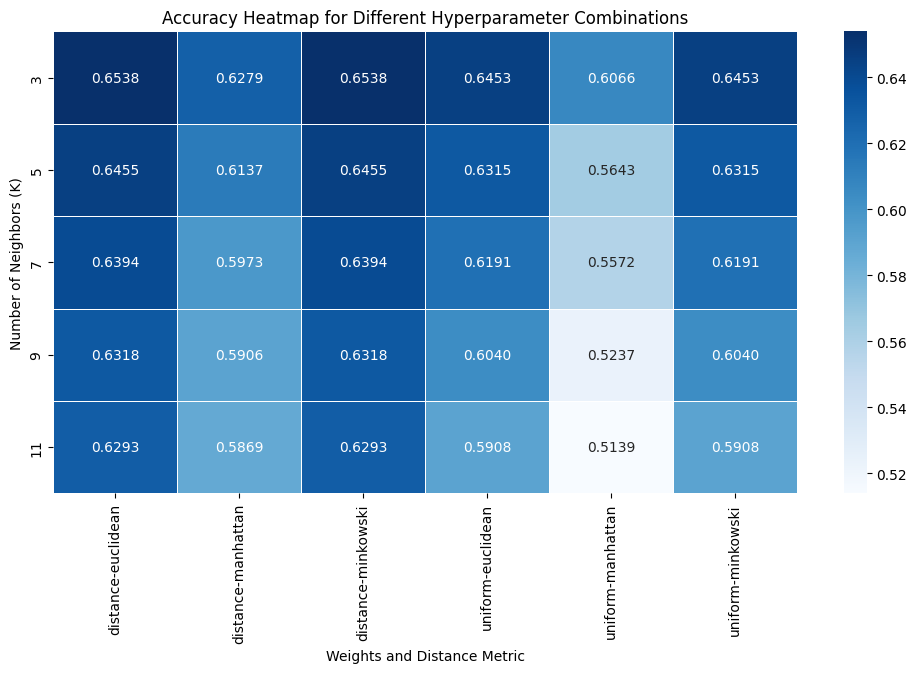

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
results = pd.DataFrame(grid_search.cv_results_)
results_pivot = results.pivot_table(values='mean_test_score', index='param_n_neighbors',
                                    columns=['param_weights', 'param_metric'])
plt.figure(figsize=(12, 6))
sns.heatmap(results_pivot, annot=True, fmt=".4f", cmap="Blues", linewidths=0.5)
plt.title("Accuracy Heatmap for Different Hyperparameter Combinations")
plt.xlabel("Weights and Distance Metric")
plt.ylabel("Number of Neighbors (K)")
plt.show()


In [53]:
knn = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='euclidean')
knn.fit(X_train, y_train)
y_pred1 = knn.predict(X_test)
print('Accuracy of KNN classifier on test set: {:.2f}'.format(knn.score(X_test, y_test)))

Accuracy of KNN classifier on test set: 0.67


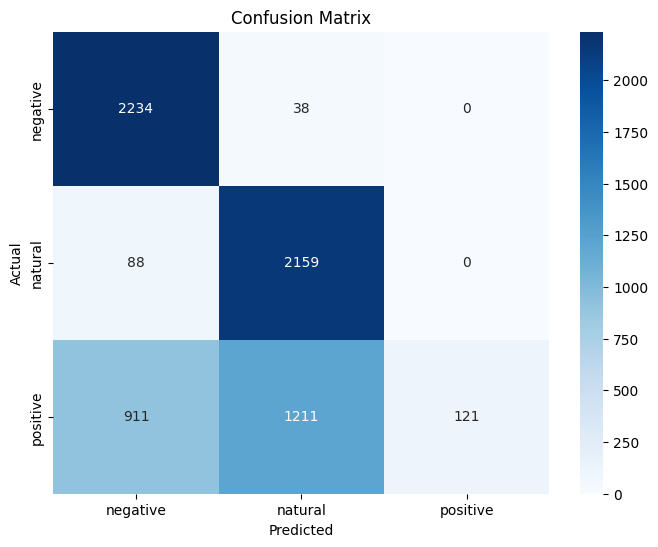

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute the confusion matrix
cmknn = confusion_matrix(y_test, y_pred1)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cmknn, annot=True, fmt="d", cmap="Blues",
            xticklabels=['negative', 'natural', 'positive'],
            yticklabels=['negative', 'natural', 'positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [55]:
from sklearn.metrics import classification_report
crknn = classification_report(y_test, y_pred1)
print("Classification Report:\n",classification_report(y_test, y_pred1))

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.98      0.81      2272
           1       0.63      0.96      0.76      2247
           2       1.00      0.05      0.10      2243

    accuracy                           0.67      6762
   macro avg       0.77      0.67      0.56      6762
weighted avg       0.77      0.67      0.56      6762



## Logistic Regression

In [75]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
import warnings
warnings.simplefilter("ignore")

param_grid = {'C': np.logspace(-4, 4, 50)}
clf = GridSearchCV(LogisticRegression(random_state=0,max_iter=2000), param_grid,cv=5, verbose=0,n_jobs=-1)
best_model = clf.fit(X_train,y_train)

print(best_model.best_estimator_)
print("Best hyperparameters:", best_model.best_params_)
print("Best accuracy:", best_model.best_score_)
print("The mean accuracy of the model is:",best_model.score(X_test,y_test))


LogisticRegression(C=np.float64(10000.0), max_iter=2000, random_state=0)
Best hyperparameters: {'C': np.float64(10000.0)}
Best accuracy: 0.934723520697905
The mean accuracy of the model is: 0.9418811002661934


In [76]:
results = pd.DataFrame(clf.cv_results_)
top_results = results[['param_C', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head(100)
top_results

,param_C,mean_test_score
49,10000.000000,0.934724
48,6866.488450,0.932850
46,3237.457543,0.932751
47,4714.866363,0.932554
45,2222.996483,0.930237
44,1526.417967,0.929497
43,1048.113134,0.925997
42,719.685673,0.924124
41,494.171336,0.922004
40,339.322177,0.921560


In [77]:
logreg = LogisticRegression(C=10000, random_state=0)
logreg.fit(X_train, y_train)
y_pred2 = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.94


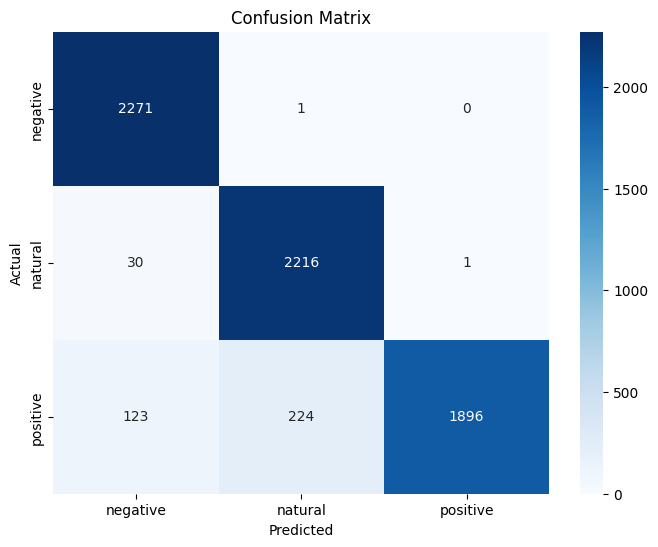

In [79]:

cmlr = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(8, 6))
sns.heatmap(cmlr, annot=True, fmt="d", cmap="Blues",
            xticklabels=['negative', 'natural', 'positive'],
            yticklabels=['negative', 'natural', 'positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [80]:
clr = classification_report(y_test, y_pred2)
print("Classification Report:\n",classification_report(y_test, y_pred2))

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      2272
           1       0.91      0.99      0.95      2247
           2       1.00      0.85      0.92      2243

    accuracy                           0.94      6762
   macro avg       0.95      0.94      0.94      6762
weighted avg       0.95      0.94      0.94      6762



# **Compare 2 Models**



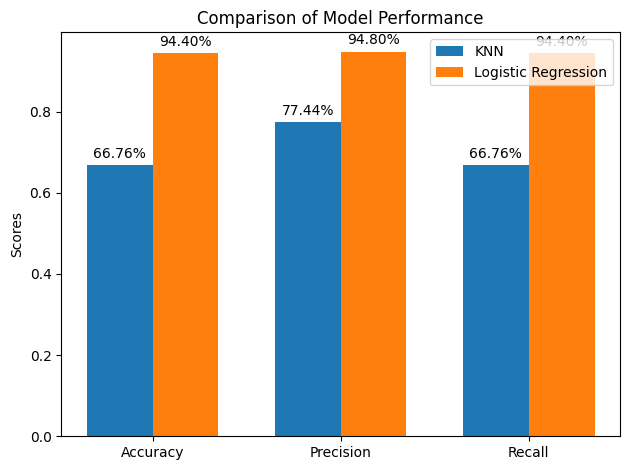

In [61]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score


knn_accuracy = accuracy_score(y_test, y_pred1)
knn_precision = precision_score(y_test, y_pred1, average='weighted')
knn_recall = recall_score(y_test, y_pred1, average='weighted')


lr_accuracy = accuracy_score(y_test, y_pred2)
lr_precision = precision_score(y_test, y_pred2, average='weighted')
lr_recall = recall_score(y_test, y_pred2, average='weighted')

metrics = ['Accuracy', 'Precision', 'Recall']
knn_scores = [knn_accuracy, knn_precision, knn_recall]
lr_scores = [lr_accuracy, lr_precision, lr_recall]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, knn_scores, width, label='KNN')
rects2 = ax.bar(x + width/2, lr_scores, width, label='Logistic Regression')

ax.set_ylabel('Scores')
ax.set_title('Comparison of Model Performance')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2%}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

# **Evaluation**

> Test the best-performing model on the evaluation dataset.


In [62]:
stop_words = set([
    'yourselves', 'between', 'whom', 'itself', 'is', "she's", 'up', 'herself',
    'here', 'your', 'each', 'we', 'he', 'my', "you've", 'having', 'in', 'both',
    'for', 'themselves', 'are', 'them', 'other', 'and', 'an', 'during', 'their',
    'can', 'yourself', 'she', 'until', 'so', 'these', 'ours', 'above', 'what',
    'while', 'have', 're', 'more', 'only', "needn't", 'when', 'just', 'that',
    'were', "don't", 'very', 'should', 'any', 'y', 'isn', 'who',  'a', 'they',
    'to', 'too', "should've", 'has', 'before', 'into', 'yours', "it's", 'do',
    'against', 'on',  'now', 'her', 've', 'd', 'by', 'am', 'from', 'about',
    'further', "that'll", "you'd", 'you', 'as', 'how', 'been', 'the', 'or',
    'doing', 'such', 'his', 'himself', 'ourselves',  'was', 'through', 'out',
    'below', 'own', 'myself', 'theirs', 'me', 'why', 'once',  'him', 'than',
    'be', 'most', "you'll", 'same', 'some', 'with', 'few', 'it', 'at', 'after',
    'its', 'which', 'there','our', 'this', 'hers', 'being', 'did', 'of', 'had',
    'under', 'over','again', 'where', 'those', 'then', "you're", 'i', 'because',
    'does', 'all'
])

def predict_sentiment(text):
  # Preprocess the input text
  text = remove_numbers(text)
  text = remove_punctuation(text)
  text = remove_extra_white_spaces(text)
  text = remove_nonEng(text)
  text = remove_stopwords(text)
  text = lemmatizing(text)

  # Transform the text using the fitted TF-IDF vectorizer
  text_tfidf = tfidf_vectorizer.transform([text])

  # Make the prediction using the trained logistic regression model
  prediction = logreg.predict(text_tfidf)[0]

  # Inverse transform the prediction to get the original sentiment label
  sentiment = label_encoder.inverse_transform([prediction])[0]
  return sentiment
test_texts = [
    "Worth the price. This is a nice one.",
    "The quality of this item is terrible. I'm very disappointed.",
    "It's an okay product. Nothing special."
]

for text in test_texts:
    predicted_sentiment = predict_sentiment(text)
    print(f"Text: '{text}'")
    print(f"Predicted Sentiment: {predicted_sentiment}")
    print("-" * 20)

Text: 'Worth the price. This is a nice one.'
Predicted Sentiment: positive
--------------------
Text: 'The quality of this item is terrible. I'm very disappointed.'
Predicted Sentiment: negative
--------------------
Text: 'It's an okay product. Nothing special.'
Predicted Sentiment: neutral
--------------------
